# Multi-Task v5 — Manual Cobb Warmup

Highest-EV follow-up to [[Open_Questions]] Q-02.1 (resolved 2026-05-02). The fixed-weight control showed that v4's 5.79° MAE = warmup curriculum + post-clamp fixed weights, with the warmup as the load-bearing piece. This notebook replicates Kendall's *implicit* cobb-warmup as an *explicit* schedule, without the saturation pathology.

Recipe (deltas vs v4_fixedweight):
- Loss: `CobbWarmupLoss` — `w_cobb` ramps linearly `0.5 → 2.2408` over ep 0–30, fixed at 2.2408 afterward. `w_seg = 2.2408` constant. `w_kpt = 1.0` constant. No Kendall, no log_var.
- Training loop calls `loss_module.set_epoch(epoch)` at the start of each epoch so the schedule advances.
- Checkpoints: `ai/models/checkpoints/multitask_v5_cobb_warmup/<timestamp>_<hash>/`.
- Everything else identical: same `SEED=42`, `augment_v5_cobb_aware`, patience 25, dual-checkpoint policy, trainable index, train/val split.

Why ramp only cobb (not seg): Q-02.1 showed dice was matched between Kendall and constant `(2.24, 2.24, 1.0)` — so the seg ramp Kendall did (0.5 → 2.24 over ep 0–~90) was not load-bearing for dice. Only cobb matters.

Why ramp over 30 epochs: matches Kendall's effective cobb-ramp window in v4 — `w_cobb` saturated at the lower clamp at ep 31 (i.e. went from `0.5·exp(0)=0.5` at init to `0.5·exp(1.5)≈2.24` at saturation over the first ~30 epochs).

Decision criteria:
- Best cobb MAE within ±0.5° of v4's 5.79° → cobb-only ramp is sufficient. Adopt as production recipe; `MixedLoss` retired.
- Best cobb MAE between 5.79° and 6.69° → partial recovery; consider also ramping `w_seg`.
- Best cobb MAE ≥ 6.69° (matches Q-02.1) → cobb-ramp alone is not what matters; investigate something else (DWA / GradNorm / gradient conflict via PCGrad).
- Best dice should remain within ±0.01 of 0.680 in all scenarios (seg head doesn't care).

References: [[2026-05-02_v4_fixedweight_control]] (Q-02.1), [[Multi_task_weighting]], [[MultiTaskEncoderUNetV4]].

## 0 · Setup

In [1]:
import math
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from torch.utils.data import DataLoader, Dataset
from torchvision import models

warnings.filterwarnings("ignore", message=".*lerp.*")

In [2]:
def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "params.yaml").exists():
            return p
    raise FileNotFoundError("params.yaml not found above CWD")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

PARAMS = yaml.safe_load((REPO_ROOT / "params.yaml").read_text())
SEED = int(PARAMS["data"]["random_seed"])

torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    try:
        import torch_directml
        DEVICE = torch_directml.device()
    except ImportError:
        DEVICE = torch.device("cpu")
print(f"repo={REPO_ROOT}\ndevice={DEVICE}\nseed={SEED}")

repo=/home/ortiz/scoliosis
device=privateuseone:0
seed=42


In [3]:
from ai.evaluation.cobb import cobb_from_segmentation_tangent
from ai.preprocessing.keypoints import (
    KEYPOINTS_PER_VERTEBRA,
    TOTAL_KEYPOINTS,
    multiclass_mask_to_keypoints,
)
from ai.preprocessing.segmentation import NUM_SEG_CLASSES
from ai.training.augmentation import (
    affine_transform,
    clahe_like,
    coarse_dropout,
    elastic_deform,
    gamma_correction,
    gaussian_blur,
    gaussian_noise,
    horizontal_flip,
    intensity_jitter,
)
from ai.training.dataset import (
    IMG_H,
    IMG_W,
    TARGET_IDS_V2,
    preprocess_case,
)
from ai.training.losses import seg_loss_fn

NUM_VERT = len(TARGET_IDS_V2)
print(f"size={IMG_H}x{IMG_W}  seg_classes={NUM_SEG_CLASSES}  vertebrae={NUM_VERT}  keypoints={TOTAL_KEYPOINTS}")


size=512x256  seg_classes=18  vertebrae=17  keypoints=68


In [4]:
CLEAN_INDEX_CSV = REPO_ROOT / "data" / "processed" / "audit_v2_corrected" / "clean_index.csv"

def load_clean_index(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"{path} missing — run audit generation first")
    return pd.read_csv(path)

def trainable_rows(df: pd.DataFrame, min_vertebrae: int = 14) -> pd.DataFrame:
    mask = df["status"].isin(["ok", "warn"])
    if "target_vertebrae_count" in df.columns:
        mask = mask & (df["target_vertebrae_count"] >= min_vertebrae)
    return df[mask].reset_index(drop=True)

def split_train_val(df: pd.DataFrame, val_frac: float = 0.2, seed: int = SEED) -> tuple[pd.DataFrame, pd.DataFrame]:
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    n_val = max(1, int(round(len(shuffled) * val_frac)))
    return shuffled.iloc[n_val:].reset_index(drop=True), shuffled.iloc[:n_val].reset_index(drop=True)

CLEAN_INDEX = load_clean_index(CLEAN_INDEX_CSV)
TRAINABLE = trainable_rows(CLEAN_INDEX)
TRAIN_DF, VAL_DF = split_train_val(TRAINABLE, val_frac=0.2, seed=SEED)
n_with_cobb = TRAINABLE["cobb_angle_deg"].notna().sum()
print(f"total={len(CLEAN_INDEX)}  trainable={len(TRAINABLE)} (cobb_gt={n_with_cobb})  train={len(TRAIN_DF)}  val={len(VAL_DF)}")

total=250  trainable=249 (cobb_gt=178)  train=199  val=50


## 1 · I/O Contract — Three Targets per Sample

| Tensor | Shape | Dtype | Source | Notes |
|---|---|---|---|---|
| `image` | `(1, 512, 256)` | float32 | grayscale X-ray, normalized to `[0, 1]` | |
| `seg` | `(512, 256)` | int64 | per-pixel class `0..17` | |
| `kpt_heatmap` | `(68, 128, 64)` | float32 | Gaussian blob per corner at H/4 × W/4 | zeros where vertebra missing |
| `kpt_valid` | `(68,)` | bool | mask of finite keypoints | warn cases (14–16 vert) have ≤16 valid groups |
| `cobb` | `()` | float32 | scalar Cobb angle (degrees) | NaN when missing |
| `cobb_valid` | `()` | bool | True if `cobb` is finite | only ~178 / 249 cases |

Heatmaps live at H/4 × W/4 (= 128 × 64) to keep the keypoint output tensor under 10 MB per sample. Argmax + ×4 scaling recovers pixel coordinates.

In [5]:
HEATMAP_DOWNSAMPLE = 4
HM_H = IMG_H // HEATMAP_DOWNSAMPLE  # 128
HM_W = IMG_W // HEATMAP_DOWNSAMPLE  # 64
HEATMAP_SIGMA = 2.0  # gaussian sigma in heatmap-resolution pixels

def render_heatmaps(
    keypoints_xy_full: np.ndarray,
    h: int = HM_H,
    w: int = HM_W,
    downsample: int = HEATMAP_DOWNSAMPLE,
    sigma: float = HEATMAP_SIGMA,
) -> tuple[np.ndarray, np.ndarray]:
    """Return (heatmaps (K,h,w) float32, valid (K,) bool)."""
    k = keypoints_xy_full.shape[0]
    hm = np.zeros((k, h, w), dtype=np.float32)
    valid = np.zeros((k,), dtype=bool)
    yy, xx = np.mgrid[0:h, 0:w].astype(np.float32)
    for i in range(k):
        x_full, y_full = keypoints_xy_full[i]
        if not (np.isfinite(x_full) and np.isfinite(y_full)):
            continue
        cx = x_full / downsample
        cy = y_full / downsample
        hm[i] = np.exp(-((xx - cx) ** 2 + (yy - cy) ** 2) / (2.0 * sigma ** 2))
        valid[i] = True
    return hm, valid


def keypoints_from_heatmaps(
    hm: torch.Tensor,
    threshold: float = 0.1,
    upsample: int = HEATMAP_DOWNSAMPLE,
) -> tuple[np.ndarray, np.ndarray]:
    """Argmax peak per channel, scale to full-resolution pixel coords.

    Args:
        hm: (K, h, w) heatmap tensor
    Returns:
        coords: (K, 2) float array of (x, y) in full-resolution pixels (NaN if peak < threshold)
        scores: (K,) peak intensities
    """
    k, h, w = hm.shape
    flat = hm.reshape(k, -1)
    scores, idx = flat.max(dim=1)
    ys = (idx // w).float() * upsample
    xs = (idx % w).float() * upsample
    coords = torch.stack([xs, ys], dim=1).cpu().numpy()
    s = scores.cpu().numpy()
    coords[s < threshold] = np.nan
    return coords, s

In [6]:
sample = TRAINABLE.iloc[0]
case = preprocess_case(sample)
kps_full = case["kps"].numpy()
hm, valid = render_heatmaps(kps_full)
cobb = sample.get("cobb_angle_deg")
print(f"image          {tuple(case['image'].shape)} {case['image'].dtype}")
print(f"seg            {tuple(case['seg'].shape)} {case['seg'].dtype}  classes={sorted(torch.unique(case['seg']).tolist())[:6]}...")
print(f"kps (full px)  {kps_full.shape} finite={int(np.isfinite(kps_full).all(axis=1).sum())}/{TOTAL_KEYPOINTS}")
print(f"heatmaps       {hm.shape}  valid={int(valid.sum())}/{TOTAL_KEYPOINTS}  peak={hm.max():.3f}")
print(f"cobb           {cobb}")

image          (1, 512, 256) torch.float32
seg            (512, 256) torch.int64  classes=[0, 1, 2, 3, 4, 5]...
kps (full px)  (68, 2) finite=68/68
heatmaps       (68, 128, 64)  valid=68/68  peak=0.999
cobb           nan


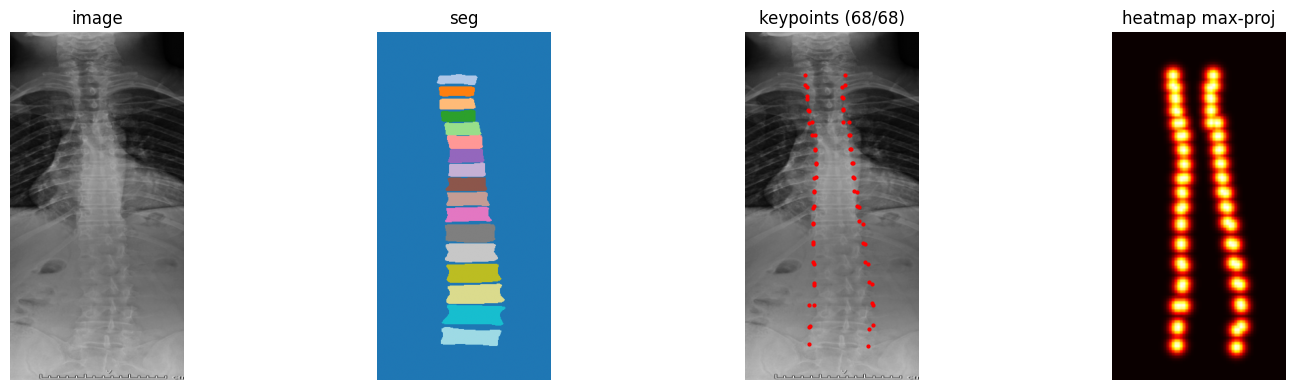

In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("image")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("seg")
# overlay first 4 keypoints (corners of T1) on image
axes[2].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(kps_full).all(axis=1)
axes[2].scatter(kps_full[fin, 0], kps_full[fin, 1], s=4, c="red")
axes[2].set_title(f"keypoints ({int(fin.sum())}/68)")
# combined heatmap (max-projection over channels)
axes[3].imshow(hm.max(axis=0), cmap="hot"); axes[3].set_title("heatmap max-proj")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 1.5 · Cobb-Preserving Augmentation (lifted from v3)


In [8]:
def augment_v5_cobb_aware(image, seg):
    """Same chain as augment_v4 but returns a `cobb_preserved` flag that is
    False when elastic_deform fires (which can change the spinal curve).
    Horizontal flip preserves |Cobb|, so it does NOT mask the Cobb target."""
    cobb_preserved = True
    if torch.rand(1).item() < 0.7:
        image, seg = affine_transform(
            image, seg,
            angle_range=(-15.0, 15.0),
            translate_frac=0.10,
            scale_range=(0.85, 1.15),
        )
    if torch.rand(1).item() < 0.5:
        image, seg = horizontal_flip(image, seg)
    if torch.rand(1).item() < 0.4:
        image, seg = elastic_deform(image, seg, alpha=40.0, sigma=6.0)
        cobb_preserved = False
    if torch.rand(1).item() < 0.5:
        image = intensity_jitter(image, gain_range=(0.7, 1.3), bias_range=(-0.15, 0.15))
    if torch.rand(1).item() < 0.3:
        image = gamma_correction(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_blur(image)
    if torch.rand(1).item() < 0.2:
        image = clahe_like(image)
    if torch.rand(1).item() < 0.3:
        image = gaussian_noise(image, std_range=(0.0, 0.08))
    if torch.rand(1).item() < 0.25:
        image = coarse_dropout(image, n_patches=12, patch_size=40)
    return image, seg, cobb_preserved


## 2 · Multi-Task Dataset

Wraps `preprocess_case` and adds heatmap rendering + Cobb extraction. Augmentation uses `augment_v5_cobb_aware` on `(image, seg)`, then **re-extracts keypoints from the augmented seg** so they always agree spatially. Cobb GT is invariant under flips and small affine, but **elastic deform** can change the spinal curve — the augmenter returns a `cobb_preserved` flag and we mask Cobb when elastic fires (cheaper than re-deriving post-deform GT).

In [9]:
class MultiTaskSpineDataset(Dataset):
    def __init__(
        self,
        df: pd.DataFrame,
        augment: bool = False,
        target_ids: tuple[int, ...] = TARGET_IDS_V2,
    ):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.target_ids = target_ids

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, i: int) -> dict[str, torch.Tensor]:
        row = self.df.iloc[i]
        case = preprocess_case(row, target_ids=self.target_ids)
        image, seg = case["image"], case["seg"]

        cobb_preserved = True
        if self.augment:
            image, seg, cobb_preserved = augment_v5_cobb_aware(image, seg)

        # re-extract keypoints from (possibly augmented) seg so they spatially agree
        seg_np = seg.numpy().astype(np.uint8)
        # remapped label space already matches target_ids index → recover raw vertebra IDs
        # by indexing back: 0=bg, 1..17 → target_ids[0..16]
        # multiclass_mask_to_keypoints expects raw IDs, so we rebuild a raw-id mask:
        raw = np.zeros_like(seg_np)
        for k_idx, raw_id in enumerate(self.target_ids, start=1):
            raw[seg_np == k_idx] = raw_id
        kps_full = multiclass_mask_to_keypoints(raw, target_ids=self.target_ids)
        hm, valid = render_heatmaps(kps_full)

        cobb_val = row.get("cobb_angle_deg")
        has_gt = pd.notna(cobb_val) and cobb_preserved
        cobb_t = torch.tensor(float(cobb_val) if has_gt else 0.0, dtype=torch.float32)
        cobb_valid = torch.tensor(bool(has_gt))

        return {
            "image": image,
            "seg": seg,
            "kpt_heatmap": torch.from_numpy(hm),
            "kpt_valid": torch.from_numpy(valid),
            "cobb": cobb_t,
            "cobb_valid": cobb_valid,
        }


def multitask_collate(batch: list[dict]) -> dict[str, torch.Tensor]:
    return {k: torch.stack([b[k] for b in batch]) for k in batch[0]}


# sanity check one batch
_ds = MultiTaskSpineDataset(TRAIN_DF.head(4), augment=False)
_b = multitask_collate([_ds[i] for i in range(4)])
for k, v in _b.items():
    print(f"  {k:14s}  {tuple(v.shape)}  {v.dtype}")


  image           (4, 1, 512, 256)  torch.float32
  seg             (4, 512, 256)  torch.int64
  kpt_heatmap     (4, 68, 128, 64)  torch.float32
  kpt_valid       (4, 68)  torch.bool
  cobb            (4,)  torch.float32
  cobb_valid      (4,)  torch.bool


## 3 · MultiTask Architecture

ResNet-34 encoder (ImageNet-pretrained, grayscale stem) shared across three heads:

- **Seg head**  — 1×1 conv on full-resolution decoder features → 18 logits per pixel (identical to `EncoderUNet`)
- **Kpt head**  — 1×1 conv on H/4 decoder features → 68 heatmaps (matches dataset target resolution, no extra upsample)
- **Cobb head** — global average pool on the bottleneck (B, 512, H/32, W/32) → 2-layer MLP → scalar (degrees)

Encoder/decoder topology mirrors `ai/models/architectures/encoder_unet.py`. Decoder features are tapped at two resolutions (H/4 for keypoints, H for seg).

In [10]:
def _conv_block(in_ch: int, out_ch: int) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
        nn.Conv2d(out_ch, out_ch, 3, padding=1),
        nn.BatchNorm2d(out_ch),
        nn.ReLU(inplace=True),
    )


class _Up(nn.Module):
    def __init__(self, in_ch: int, skip_ch: int, out_ch: int):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch // 2, 2, stride=2)
        self.conv = _conv_block(in_ch // 2 + skip_ch, out_ch)

    def forward(self, x: torch.Tensor, skip: torch.Tensor) -> torch.Tensor:
        x = self.up(x)
        dy = skip.shape[2] - x.shape[2]
        dx = skip.shape[3] - x.shape[3]
        if dy != 0 or dx != 0:
            x = F.pad(x, [dx // 2, dx - dx // 2, dy // 2, dy - dy // 2])
        return self.conv(torch.cat([x, skip], dim=1))


class MultiTaskEncoderUNet(nn.Module):
    """Shared ResNet-34 encoder with seg + keypoint + Cobb heads."""

    def __init__(
        self,
        in_ch: int = 1,
        num_seg_classes: int = NUM_SEG_CLASSES,
        num_keypoints: int = TOTAL_KEYPOINTS,
        pretrained: bool = True,
        dropout: float = 0.2,
        cobb_norm: float = 90.0,
    ):
        super().__init__()
        self.cobb_norm = cobb_norm

        weights = models.ResNet34_Weights.IMAGENET1K_V1 if pretrained else None
        backbone = models.resnet34(weights=weights)

        original_conv1 = backbone.conv1
        self.conv1 = nn.Conv2d(in_ch, 64, kernel_size=7, stride=2, padding=3, bias=False)
        if pretrained and in_ch == 1:
            self.conv1.weight.data = original_conv1.weight.data.mean(dim=1, keepdim=True)
        elif pretrained and in_ch == 3:
            self.conv1.weight.data = original_conv1.weight.data

        self.bn1 = backbone.bn1
        self.relu = backbone.relu
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up1 = _Up(512, 256, 256)
        self.up2 = _Up(256, 128, 128)
        self.up3 = _Up(128, 64, 64)   # produces (B, 64, H/4, W/4) — keypoint tap
        self.up4 = _Up(64, 64, 64)    # produces (B, 64, H/2, W/2)
        self.final_up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.drop = nn.Dropout2d(dropout)

        # heads
        self.seg_head = nn.Conv2d(64, num_seg_classes, 1)
        self.kpt_head = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_keypoints, 1),
        )
        self.cobb_head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

        self._encoder_modules = [
            self.conv1, self.bn1, self.layer1, self.layer2, self.layer3, self.layer4,
        ]
        self._decoder_modules = [
            self.up1, self.up2, self.up3, self.up4, self.final_up, self.drop,
            self.seg_head, self.kpt_head, self.cobb_head,
        ]

    def forward(self, x: torch.Tensor) -> dict[str, torch.Tensor]:
        x0 = self.relu(self.bn1(self.conv1(x)))
        x_pool = self.maxpool(x0)
        s1 = self.layer1(x_pool)
        s2 = self.layer2(s1)
        s3 = self.layer3(s2)
        bridge = self.layer4(s3)  # (B, 512, H/32, W/32) — Cobb tap

        y = self.up1(bridge, s3)
        y = self.up2(y, s2)
        y_q = self.up3(y, s1)              # (B, 64, H/4, W/4) — kpt tap
        y = self.up4(y_q, x0)
        y_full = self.final_up(y)          # (B, 64, H, W)
        y_full = self.drop(y_full)

        seg_logits = self.seg_head(y_full)
        kpt_heatmaps = self.kpt_head(y_q)  # (B, 68, H/4, W/4)
        cobb_norm_pred = self.cobb_head(bridge).squeeze(-1)  # (B,)
        cobb_pred = cobb_norm_pred * self.cobb_norm  # rescale to degrees

        return {
            "seg": seg_logits,
            "kpt": kpt_heatmaps,
            "cobb": cobb_pred,
        }

    def encoder_params(self):
        for m in self._encoder_modules:
            yield from m.parameters()

    def decoder_params(self):
        for m in self._decoder_modules:
            yield from m.parameters()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters())


model = MultiTaskEncoderUNet(pretrained=True, dropout=0.2).to(DEVICE)
n_enc = sum(p.numel() for p in model.encoder_params())
n_dec = sum(p.numel() for p in model.decoder_params())
print(f"MultiTaskEncoderUNet total params: {count_params(model):,}")
print(f"  encoder: {n_enc:,}  decoder+heads: {n_dec:,}")

MultiTaskEncoderUNet total params: 24,501,303
  encoder: 21,278,400  decoder+heads: 3,222,903


Dropped Escape call with ulEscapeCode : 0x03007703


## 4 · Forward-Pass Sanity Check

In [11]:
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
for k, v in out.items():
    print(f"  {k:6s}  {tuple(v.shape)}  {v.dtype}")

  seg     (1, 18, 512, 256)  torch.float32
  kpt     (1, 68, 128, 64)  torch.float32
  cobb    (1,)  torch.float32


## 5 · Multi-Task Loss — Manual Cobb Warmup

Three raw losses, summed with **scheduled** weights:

$$L = w_\text{seg}\,L_\text{seg} + w_\text{cobb}(\text{ep})\,L_\text{cobb} + w_\text{kpt}\,L_\text{kpt}$$

with:
- `w_seg = 2.2408` constant
- `w_cobb(ep) = 0.5 + (2.2408 - 0.5) · min(ep, 30) / 30` — linear ramp from 0.5 to 2.2408 over the first 30 epochs, then held at 2.2408
- `w_kpt = 1.0` constant

The schedule is advanced via `loss_module.set_epoch(epoch)` at the start of each epoch in the training loop. No learnable parameters.

In [12]:
COBB_NORM = 90.0
W_SEG = 0.5 * math.exp(1.5)        # 2.2408 — matches v4 post-clamp regime
W_COBB_INIT = 0.5                   # matches Kendall at log_var=0 (init)
W_COBB_FINAL = 0.5 * math.exp(1.5)  # 2.2408 — matches Kendall at log_var=-1.5 (saturation)
W_KPT = 1.0
WARMUP_RAMP_EPOCHS = 30             # matches Kendall's effective cobb-ramp window in v4


def kpt_loss_fn(pred: torch.Tensor, target: torch.Tensor, valid: torch.Tensor) -> torch.Tensor:
    """Masked MSE. valid: (B, K) bool; pred/target: (B, K, h, w)."""
    mask = valid.float().unsqueeze(-1).unsqueeze(-1)
    diff = (pred - target) ** 2 * mask
    denom = mask.sum() * pred.shape[-1] * pred.shape[-2] + 1e-6
    return diff.sum() / denom


def cobb_loss_fn(
    pred_deg: torch.Tensor,
    target_deg: torch.Tensor,
    valid: torch.Tensor,
    norm: float = COBB_NORM,
) -> torch.Tensor:
    if not bool(valid.any()):
        return pred_deg.sum() * 0.0
    p = pred_deg[valid] / norm
    t = target_deg[valid] / norm
    return F.smooth_l1_loss(p, t)


class CobbWarmupLoss(nn.Module):
    """Manual cobb-only warmup.

    `w_cobb` ramps linearly from `w_cobb_init` to `w_cobb_final` over `ramp_epochs`,
    then is held at `w_cobb_final`. `w_seg` and `w_kpt` are constant. The training
    loop must call `set_epoch(epoch)` at the start of each epoch so the schedule
    advances; we initialize `_epoch=0`.
    """

    def __init__(
        self,
        w_seg: float = W_SEG,
        w_cobb_init: float = W_COBB_INIT,
        w_cobb_final: float = W_COBB_FINAL,
        w_kpt: float = W_KPT,
        ramp_epochs: int = WARMUP_RAMP_EPOCHS,
    ) -> None:
        super().__init__()
        self.w_seg = float(w_seg)
        self.w_cobb_init = float(w_cobb_init)
        self.w_cobb_final = float(w_cobb_final)
        self.w_kpt = float(w_kpt)
        self.ramp_epochs = int(ramp_epochs)
        self._epoch = 0  # 0-based; set_epoch(0) is implicit

    def set_epoch(self, epoch: int) -> None:
        self._epoch = int(epoch)

    @property
    def w_cobb(self) -> float:
        if self.ramp_epochs <= 0:
            return self.w_cobb_final
        frac = min(self._epoch, self.ramp_epochs) / self.ramp_epochs
        return self.w_cobb_init + (self.w_cobb_final - self.w_cobb_init) * frac

    def forward(self, raws: dict[str, torch.Tensor]) -> tuple[torch.Tensor, dict[str, float]]:
        w_cobb = self.w_cobb
        total = self.w_seg * raws["seg"] + w_cobb * raws["cobb"] + self.w_kpt * raws["kpt"]
        parts = {
            "raw_seg": float(raws["seg"].detach().cpu()),
            "raw_kpt": float(raws["kpt"].detach().cpu()),
            "raw_cobb": float(raws["cobb"].detach().cpu()),
            "weight_seg": self.w_seg,
            "weight_cobb": w_cobb,
            "weight_kpt": self.w_kpt,
            "loss": float(total.detach().cpu()),
        }
        return total, parts


def raw_losses_for(out: dict, batch: dict, dev: torch.device) -> dict[str, torch.Tensor]:
    return {
        "seg": seg_loss_fn(out["seg"], batch["seg"].to(dev), NUM_SEG_CLASSES),
        "kpt": kpt_loss_fn(
            out["kpt"],
            batch["kpt_heatmap"].to(dev),
            batch["kpt_valid"].to(dev),
        ),
        "cobb": cobb_loss_fn(
            out["cobb"],
            batch["cobb"].to(dev),
            batch["cobb_valid"].to(dev),
        ),
    }


## 6 · Training Loop

Same recipe as v4_fixedweight: encoder freeze warmup (10 epochs), unfreeze with cosine LR. Differentiated LRs (encoder 1e-4, decoder 1e-3). No `LR_LOGVAR` — `CobbWarmupLoss` has no learnable parameters. Patience 25 on **mean val dice**. Dual-checkpoint policy: `model.pt` = best dice, `model_best_cobb.pt` = best Cobb MAE.

**New:** training loop calls `loss_module.set_epoch(epoch - 1)` at the start of each epoch (so `epoch=1` corresponds to `_epoch=0`, the start of the ramp) before any forward pass.

Caching: per-config checkpoint under `ai/models/checkpoints/multitask_v5_cobb_warmup/<timestamp>_<hash>/`. The config hash includes `loss: "cobb_warmup_30ep_0.5_to_2.24"` so this run cannot collide with v4 / v4_fixedweight.

In [13]:
import hashlib
import json
from datetime import datetime

CHECKPOINT_ROOT = REPO_ROOT / "ai" / "models" / "checkpoints" / "multitask_v5_cobb_warmup"
CHECKPOINT_ROOT.mkdir(parents=True, exist_ok=True)

NUM_EPOCHS = 150
BATCH_SIZE = 4
LR_ENCODER = 1e-4
LR_DECODER = 1e-3
WEIGHT_DECAY = 2e-4
WARMUP_EPOCHS = 10
PATIENCE = 25
DROPOUT = 0.2


def run_config() -> dict:
    return {
        "dataset": "v2_corrected",
        "arch": "MultiTaskEncoderUNetV4",
        "encoder": "resnet34",
        "num_seg_classes": NUM_SEG_CLASSES,
        "num_keypoints": TOTAL_KEYPOINTS,
        "heatmap_h": HM_H,
        "heatmap_w": HM_W,
        "heatmap_sigma": HEATMAP_SIGMA,
        "loss": "cobb_warmup_30ep_0.5_to_2.24",
        "w_seg": W_SEG,
        "w_cobb_init": W_COBB_INIT,
        "w_cobb_final": W_COBB_FINAL,
        "w_kpt": W_KPT,
        "warmup_ramp_epochs": WARMUP_RAMP_EPOCHS,
        "cobb_norm": COBB_NORM,
        "augment": "v5_cobb_aware",
        "num_epochs": NUM_EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr_encoder": LR_ENCODER,
        "lr_decoder": LR_DECODER,
        "weight_decay": WEIGHT_DECAY,
        "warmup_epochs": WARMUP_EPOCHS,
        "patience": PATIENCE,
        "dropout": DROPOUT,
        "seed": SEED,
        "trainable_count": int(len(TRAINABLE)),
        "val_frac": 0.2,
    }


def cfg_hash(cfg: dict) -> str:
    return hashlib.sha256(json.dumps(cfg, sort_keys=True, default=str).encode()).hexdigest()[:8]


def find_cached(cfg: dict) -> Path | None:
    h = cfg_hash(cfg)
    for p in sorted(CHECKPOINT_ROOT.glob(f"*_{h}")):
        if (p / "model.pt").exists():
            return p
    return None


def new_run_dir(cfg: dict) -> Path:
    stamp = datetime.now().strftime("%Y%m%dT%H%M")
    p = CHECKPOINT_ROOT / f"{stamp}_{cfg_hash(cfg)}"
    p.mkdir(parents=True, exist_ok=True)
    return p


In [14]:
def train_step(
    model: nn.Module,
    loss_module: nn.Module,
    batch: dict,
    optimizer: torch.optim.Optimizer,
) -> dict[str, float]:
    out = model(batch["image"].to(DEVICE))
    raws = raw_losses_for(out, batch, DEVICE)
    total, parts = loss_module(raws)
    optimizer.zero_grad()
    total.backward()
    optimizer.step()
    return parts


@torch.no_grad()
def validate(model: nn.Module, loss_module: nn.Module, loader: DataLoader) -> dict[str, float]:
    model.eval()
    accum = {
        "loss": 0.0,
        "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0,
        "weight_seg": 0.0, "weight_cobb": 0.0,
    }
    inter = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    card = torch.zeros(NUM_SEG_CLASSES - 1, device=DEVICE)
    cobb_abs_err: list[float] = []
    n_batches = 0
    for batch in loader:
        out = model(batch["image"].to(DEVICE))
        raws = raw_losses_for(out, batch, DEVICE)
        total, parts = loss_module(raws)
        accum["loss"] += float(total.detach().cpu())
        for k in ("raw_seg", "raw_kpt", "raw_cobb", "weight_seg", "weight_cobb"):
            accum[k] += parts[k]

        pred_mask = out["seg"].argmax(dim=1)
        seg_t = batch["seg"].to(DEVICE)
        for c in range(1, NUM_SEG_CLASSES):
            p, g = (pred_mask == c), (seg_t == c)
            inter[c - 1] += (p & g).sum()
            card[c - 1] += p.sum() + g.sum()

        valid = batch["cobb_valid"]
        if valid.any():
            cobb_pred = out["cobb"].cpu()[valid]
            cobb_true = batch["cobb"][valid]
            cobb_abs_err.extend((cobb_pred - cobb_true).abs().tolist())
        n_batches += 1

    dice_per_cls = (2.0 * inter) / card.clamp(min=1e-6)
    valid_cls = card > 0
    return {
        **{k: v / max(1, n_batches) for k, v in accum.items()},
        "dice": float(dice_per_cls[valid_cls].mean()) if valid_cls.any() else float("nan"),
        "cobb_mae_direct": float(np.mean(cobb_abs_err)) if cobb_abs_err else float("nan"),
    }


In [15]:
cfg = run_config()
_cached = find_cached(cfg)
loss_module = CobbWarmupLoss().to(DEVICE)

if _cached is not None:
    state = torch.load(_cached / "model.pt", map_location=DEVICE)
    history_df = pd.read_csv(_cached / "history.csv")
    metrics_cache = json.loads((_cached / "metrics.json").read_text())
    model = MultiTaskEncoderUNet(pretrained=False, dropout=DROPOUT).to(DEVICE)
    model.load_state_dict(state["model"])
    best_dice = float(metrics_cache["best_val_dice"])
    best_cobb_mae = float(metrics_cache.get("best_val_cobb_mae", float("nan")))
    print(
        f"reused cached run <- {_cached.relative_to(REPO_ROOT)}  "
        f"best_dice={best_dice:.3f}  best_cobb_mae={best_cobb_mae:.2f}°"
    )
else:
    model = MultiTaskEncoderUNet(pretrained=True, dropout=DROPOUT).to(DEVICE)
    print(f"MultiTaskEncoderUNet params: {count_params(model):,}  dropout={DROPOUT}")

    train_loader = DataLoader(
        MultiTaskSpineDataset(TRAIN_DF, augment=True),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=multitask_collate,
    )
    val_loader = DataLoader(
        MultiTaskSpineDataset(VAL_DF, augment=False),
        batch_size=BATCH_SIZE, shuffle=False, collate_fn=multitask_collate,
    )

    for p in model.encoder_params():
        p.requires_grad = False
    optimizer = torch.optim.Adam([
        {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
    ])
    scheduler = None

    history: list[dict[str, float]] = []
    best_dice = -1.0
    best_cobb_mae = float("inf")
    best_dice_state: dict | None = None
    best_cobb_state: dict | None = None
    best_dice_epoch = -1
    best_cobb_epoch = -1
    no_improve = 0  # tracked against dice for early stopping

    t_start = time.time()
    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()
        loss_module.set_epoch(epoch - 1)  # advance the cobb-warmup schedule

        if epoch == WARMUP_EPOCHS + 1:
            for p in model.encoder_params():
                p.requires_grad = True
            optimizer = torch.optim.Adam([
                {"params": model.encoder_params(), "lr": LR_ENCODER, "weight_decay": WEIGHT_DECAY},
                {"params": model.decoder_params(), "lr": LR_DECODER, "weight_decay": WEIGHT_DECAY},
            ])
            scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                optimizer, T_max=NUM_EPOCHS - WARMUP_EPOCHS
            )
            print(f"  >>> encoder unfrozen at epoch {epoch}")

        model.train()
        train_acc = {"loss": 0.0, "raw_seg": 0.0, "raw_kpt": 0.0, "raw_cobb": 0.0}
        n_steps = 0
        for batch in train_loader:
            parts = train_step(model, loss_module, batch, optimizer)
            train_acc["loss"] += parts["loss"]
            for k in ("raw_seg", "raw_kpt", "raw_cobb"):
                train_acc[k] += parts[k]
            n_steps += 1
        train_acc = {k: v / max(1, n_steps) for k, v in train_acc.items()}

        val_stats = validate(model, loss_module, val_loader)
        if scheduler is not None:
            scheduler.step()

        n_groups = len(optimizer.param_groups)
        row = {
            "epoch":         epoch,
            "train_loss":    train_acc["loss"],
            "train_seg":     train_acc["raw_seg"],
            "train_kpt":     train_acc["raw_kpt"],
            "train_cobb":    train_acc["raw_cobb"],
            "val_loss":      val_stats["loss"],
            "val_seg":       val_stats["raw_seg"],
            "val_kpt":       val_stats["raw_kpt"],
            "val_cobb":      val_stats["raw_cobb"],
            "w_seg":         val_stats["weight_seg"],
            "w_cobb":        val_stats["weight_cobb"],
            "val_dice":      val_stats["dice"],
            "val_cobb_mae":  val_stats["cobb_mae_direct"],
            "lr_enc":        float(optimizer.param_groups[0]["lr"]) if n_groups >= 2 else 0.0,
            "lr_dec":        float(optimizer.param_groups[-1]["lr"]),
            "sec":           time.time() - t0,
        }
        history.append(row)

        improved_dice = val_stats["dice"] > best_dice
        improved_cobb = (
            not math.isnan(val_stats["cobb_mae_direct"])
            and val_stats["cobb_mae_direct"] < best_cobb_mae
        )
        if improved_dice:
            best_dice = val_stats["dice"]
            best_dice_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            }
            best_dice_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
        if improved_cobb:
            best_cobb_mae = val_stats["cobb_mae_direct"]
            best_cobb_state = {
                "model": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()},
            }
            best_cobb_epoch = epoch

        flags = ""
        if improved_dice:
            flags += " *D"
        if improved_cobb:
            flags += " *C"
        print(
            f"ep {epoch:3d}/{NUM_EPOCHS}  "
            f"tr={row['train_loss']:6.3f} (s={row['train_seg']:.2f} k={row['train_kpt']:.3f} c={row['train_cobb']:.3f})  "
            f"val={row['val_loss']:6.3f}  dice={row['val_dice']:.3f}  cobb={row['val_cobb_mae']:5.1f}°  "
            f"w[s/c]={row['w_seg']:.2f}/{row['w_cobb']:.2f}  ({row['sec']:.1f}s){flags}"
        )

        if epoch > WARMUP_EPOCHS and no_improve >= PATIENCE:
            print(f"\n  >>> early stop at epoch {epoch}, no dice improvement for {PATIENCE} epochs")
            break

    # restore the best-dice state into the live model (eval cells consume it)
    if best_dice_state is not None:
        model.load_state_dict(best_dice_state["model"])
    history_df = pd.DataFrame(history)

    run_dir = new_run_dir(cfg)
    if best_dice_state is not None:
        torch.save(best_dice_state, run_dir / "model.pt")  # primary ckpt = best dice
    if best_cobb_state is not None:
        torch.save(best_cobb_state, run_dir / "model_best_cobb.pt")
    history_df.to_csv(run_dir / "history.csv", index=False)
    (run_dir / "config.json").write_text(json.dumps(cfg, indent=2, default=str))
    (run_dir / "metrics.json").write_text(json.dumps({
        "best_val_dice": best_dice,
        "best_val_dice_epoch": best_dice_epoch,
        "best_val_cobb_mae": best_cobb_mae if best_cobb_mae != float("inf") else None,
        "best_val_cobb_mae_epoch": best_cobb_epoch,
        "stopped_epoch": int(history_df["epoch"].iloc[-1]),
        "weights_init": {"seg": loss_module.w_seg, "cobb": loss_module.w_cobb_init, "kpt": loss_module.w_kpt},
        "weights_final": {"seg": loss_module.w_seg, "cobb": loss_module.w_cobb_final, "kpt": loss_module.w_kpt},
        "warmup_ramp_epochs": loss_module.ramp_epochs,
    }, indent=2))
    print(
        f"\ntotal time: {time.time() - t_start:.1f}s  "
        f"best dice={best_dice:.3f}@ep{best_dice_epoch}  "
        f"best cobb_mae={best_cobb_mae:.2f}°@ep{best_cobb_epoch}"
    )
    print(f"saved -> {run_dir.relative_to(REPO_ROOT)}")


MultiTaskEncoderUNet params: 24,501,303  dropout=0.2
ep   1/150  tr= 3.154 (s=1.39 k=0.020 c=0.054)  val= 3.105  dice=0.061  cobb= 17.9°  w[s/c]=2.24/0.50  (16.6s) *D *C
ep   2/150  tr= 2.635 (s=1.16 k=0.003 c=0.045)  val= 2.471  dice=0.138  cobb= 17.5°  w[s/c]=2.24/0.56  (13.3s) *D *C
ep   3/150  tr= 2.438 (s=1.08 k=0.002 c=0.030)  val= 2.337  dice=0.156  cobb= 17.8°  w[s/c]=2.24/0.62  (13.2s) *D
ep   4/150  tr= 2.321 (s=1.03 k=0.002 c=0.027)  val= 2.417  dice=0.131  cobb= 21.8°  w[s/c]=2.24/0.67  (15.9s)
ep   5/150  tr= 2.261 (s=1.00 k=0.002 c=0.024)  val= 2.224  dice=0.190  cobb= 17.4°  w[s/c]=2.24/0.73  (13.3s) *D *C
ep   6/150  tr= 2.173 (s=0.96 k=0.002 c=0.036)  val= 2.167  dice=0.227  cobb= 19.5°  w[s/c]=2.24/0.79  (15.6s) *D
ep   7/150  tr= 2.137 (s=0.94 k=0.002 c=0.026)  val= 1.989  dice=0.330  cobb= 20.4°  w[s/c]=2.24/0.85  (13.1s) *D
ep   8/150  tr= 2.124 (s=0.94 k=0.002 c=0.029)  val= 1.928  dice=0.318  cobb= 20.4°  w[s/c]=2.24/0.91  (13.1s)
ep   9/150  tr= 2.051 (s=0.90 k=

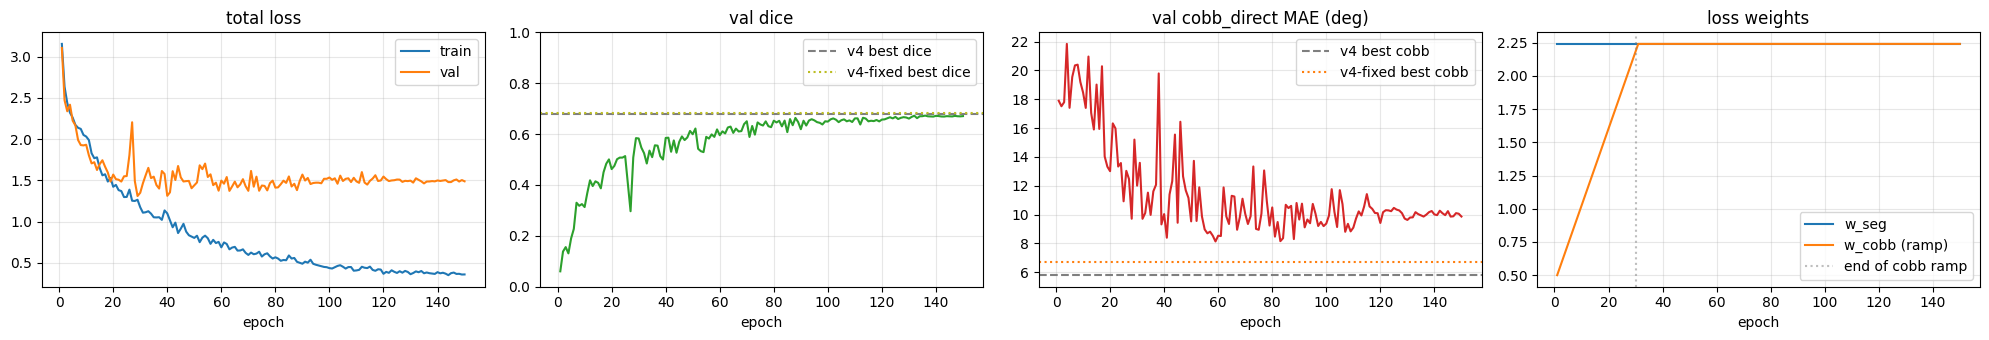

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 3.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], label="train")
axes[0].plot(history_df["epoch"], history_df["val_loss"],   label="val")
axes[0].set(title="total loss", xlabel="epoch")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history_df["epoch"], history_df["val_dice"], color="tab:green")
axes[1].axhline(0.680, color="tab:gray", linestyle="--", label="v4 best dice")
axes[1].axhline(0.683, color="tab:olive", linestyle=":", label="v4-fixed best dice")
axes[1].set(title="val dice", xlabel="epoch", ylim=(0.0, 1.0))
axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(history_df["epoch"], history_df["val_cobb_mae"], color="tab:red")
axes[2].axhline(5.79, color="tab:gray", linestyle="--", label="v4 best cobb")
axes[2].axhline(6.69, color="tab:orange", linestyle=":", label="v4-fixed best cobb")
axes[2].set(title="val cobb_direct MAE (deg)", xlabel="epoch")
axes[2].legend(); axes[2].grid(alpha=0.3)

axes[3].plot(history_df["epoch"], history_df["w_seg"],  label="w_seg")
axes[3].plot(history_df["epoch"], history_df["w_cobb"], label="w_cobb (ramp)")
axes[3].axvline(WARMUP_RAMP_EPOCHS, color="tab:gray", linestyle=":", alpha=0.5, label="end of cobb ramp")
axes[3].set(title="loss weights", xlabel="epoch")
axes[3].legend(); axes[3].grid(alpha=0.3)

plt.tight_layout(); plt.show()


## 7 · Evaluation — Three Cobb Estimators

The multi-task model exposes **three independent paths** to a Cobb angle for the same case:

1. **Direct** — `cobb_head` scalar output
2. **From keypoints** — argmax peaks of the keypoint heatmaps → endplate slopes → Cobb
3. **From segmentation** — `seg_head` argmax → existing `cobb_from_segmentation_tangent`

Compare against ground-truth `cobb_angle_deg` to see which path the multi-task encoder produces best, and whether ensembling all three helps.

In [17]:
def cobb_from_keypoints(coords_xy: np.ndarray, num_vert: int = NUM_VERT) -> float:
    """Brute-force pairwise endplate angle.

    coords_xy: (68, 2) float, NaN where keypoint missing. Order: TL, TR, BL, BR per vertebra.
    Returns max absolute difference (deg) between any two endplate slopes.
    """
    angles_top = []
    angles_bot = []
    indices = []
    for v in range(num_vert):
        tl, tr, bl, br = coords_xy[4 * v : 4 * v + 4]
        if np.isfinite(tl).all() and np.isfinite(tr).all():
            dy = tr[1] - tl[1]
            dx = tr[0] - tl[0]
            angles_top.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_top.append(np.nan)
        if np.isfinite(bl).all() and np.isfinite(br).all():
            dy = br[1] - bl[1]
            dx = br[0] - bl[0]
            angles_bot.append(math.degrees(math.atan2(dy, dx)))
        else:
            angles_bot.append(np.nan)
        indices.append(v)
    a = np.array(angles_top + angles_bot)
    a = a[np.isfinite(a)]
    if len(a) < 2:
        return float("nan")
    diffs = np.abs(a[:, None] - a[None, :])
    return float(diffs.max())


@torch.no_grad()
def evaluate_case(model: nn.Module, row: pd.Series) -> dict:
    case = preprocess_case(row)
    out = model(case["image"].unsqueeze(0).to(DEVICE))
    seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
    kpt_hm = out["kpt"].squeeze(0).cpu()
    cobb_direct = float(out["cobb"].squeeze(0).cpu())

    # dice (mean over present target classes)
    dice_scores: list[float] = []
    for c in range(1, NUM_SEG_CLASSES):
        p, g = (seg_pred == c), (case["seg"] == c)
        denom = p.sum() + g.sum()
        if denom > 0:
            dice_scores.append(float(2.0 * (p & g).sum() / denom))
    dice_mean = float(np.mean(dice_scores)) if dice_scores else float("nan")

    # Cobb from seg pipeline (existing)
    cobb_from_seg = float(cobb_from_segmentation_tangent(seg_pred.numpy()))
    # Cobb from keypoint heatmaps
    coords, _scores = keypoints_from_heatmaps(kpt_hm)
    cobb_from_kpt = cobb_from_keypoints(coords)

    out_row = {
        "dice": dice_mean,
        "cobb_direct": cobb_direct,
        "cobb_from_seg": cobb_from_seg,
        "cobb_from_kpt": cobb_from_kpt,
    }
    gt = row.get("cobb_angle_deg")
    if pd.notna(gt):
        gt = float(gt)
        out_row["cobb_true"] = gt
        for k in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
            v = out_row[k]
            out_row[f"{k}_abs_err"] = abs(v - gt) if np.isfinite(v) else float("nan")
    return out_row

eval_rows = [evaluate_case(model, r) for _, r in VAL_DF.iterrows()]
eval_df = pd.DataFrame(eval_rows)
print(f"evaluated {len(eval_df)} val cases")
eval_df.head()

evaluated 50 val cases


,dice,cobb_direct,cobb_from_seg,cobb_from_kpt,cobb_true,cobb_direct_abs_err,cobb_from_seg_abs_err,cobb_from_kpt_abs_err
0,0.635335,85.350677,76.846923,57.652557,80.171357,5.179320,3.324434,22.518801
1,0.943478,44.730225,12.128072,14.250033,NaN,NaN,NaN,NaN
2,0.440358,88.932114,123.616494,52.765166,90.000000,1.067886,33.616494,37.234834
3,0.880701,37.302334,9.924992,35.727398,NaN,NaN,NaN,NaN
4,0.881799,37.375156,43.281123,33.084853,37.935438,0.560282,5.345685,4.850585


In [18]:
summary = {
    "n_val":             int(len(eval_df)),
    "mean_dice":         float(eval_df["dice"].mean()),
}
with_gt = eval_df.dropna(subset=["cobb_true"]) if "cobb_true" in eval_df else pd.DataFrame()
if len(with_gt):
    summary["n_with_cobb_gt"] = int(len(with_gt))
    for col in ["cobb_direct", "cobb_from_seg", "cobb_from_kpt"]:
        err = with_gt[f"{col}_abs_err"].dropna()
        if len(err):
            summary[f"{col}_mae"] = float(err.mean())
            summary[f"{col}_n"] = int(len(err))

print("=== Multi-Task v5 cobb-warmup — single 80/20 split ===")
for k, v in summary.items():
    print(f"  {k:30s} {v}")
print(f"\nv3_corrected baseline (single split): val_dice ≈ 0.64")
print(f"v3_corrected pipeline floor:          ~10.4° MAE (seg from GT mask)")


=== Multi-Task v5 cobb-warmup — single 80/20 split ===
  n_val                          50
  mean_dice                      0.6711081475956255
  n_with_cobb_gt                 32
  cobb_direct_mae                9.859355410466833
  cobb_direct_n                  32
  cobb_from_seg_mae              12.94774122085291
  cobb_from_seg_n                32
  cobb_from_kpt_mae              20.407692890186063
  cobb_from_kpt_n                32

v3_corrected baseline (single split): val_dice ≈ 0.64
v3_corrected pipeline floor:          ~10.4° MAE (seg from GT mask)


## 8 · Qualitative Check

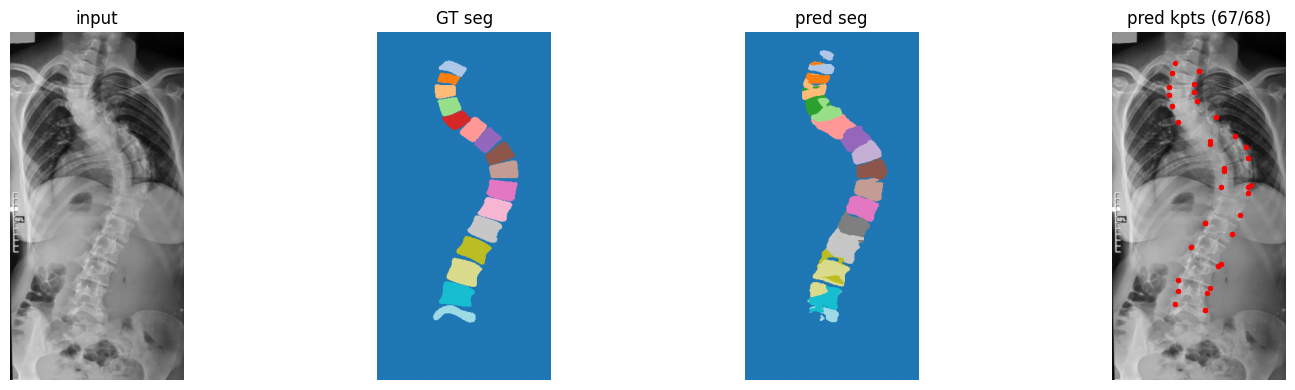

In [19]:
row = VAL_DF.iloc[0]
case = preprocess_case(row)
model.eval()
with torch.no_grad():
    out = model(case["image"].unsqueeze(0).to(DEVICE))
seg_pred = out["seg"].argmax(dim=1).squeeze(0).cpu()
kpt_hm = out["kpt"].squeeze(0).cpu()
coords, scores = keypoints_from_heatmaps(kpt_hm)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(case["image"].squeeze(0), cmap="gray"); axes[0].set_title("input")
axes[1].imshow(case["seg"], cmap="tab20"); axes[1].set_title("GT seg")
axes[2].imshow(seg_pred, cmap="tab20"); axes[2].set_title("pred seg")
axes[3].imshow(case["image"].squeeze(0), cmap="gray")
fin = np.isfinite(coords).all(axis=1)
axes[3].scatter(coords[fin, 0], coords[fin, 1], s=8, c="red")
axes[3].set_title(f"pred kpts ({int(fin.sum())}/68)")
for ax in axes:
    ax.set_axis_off()
plt.tight_layout(); plt.show()

## 9 · Conclusions

TODO after the run: dice / cobb_direct MAE / r / sev_acc vs v1 (0.684, 9.34°, 0.838, 0.844) and v3 (0.584, 8.43°, 0.873, 0.750).
If dice ≥ 0.684 AND cobb_direct MAE ≤ 9° → regularizer hypothesis confirmed; v4 → production candidate; move to 5-fold CV.
If dice ≥ 0.684 but cobb worsens vs v3 → the cobb head benefited from v3's no-kpt regime; consider a 2-stream architecture.
If neither beats v1 → v1 is production; move directly to 5-fold CV on v1.
